# Introduction to Tabular Data Analysis with Pandas

[Pandas](https://pandas.pydata.org/) is a popular Python library used for working with tabular data (similar to data stored in a spreadsheet). It provides helper functions to read data from various file formats like CSV, Excel spreadsheets, HTML tables, JSON, SQL, and more.

### What is Tabular Data?

Tabular data is data organized into rows and columns, much like a spreadsheet or a SQL table. In Pandas, this structure is called a **DataFrame**.

In this notebook, we will use a COVID-19 dataset from Italy to learn how to:

1. Load data from files
2. Inspect and clean datasets
3. Query and filter information
4. Perform statistical analysis

## Reading a CSV file using Pandas

Let's download a file `italy-covid-19-daily-stats.csv` which contains day-wise Covid-19 data for Italy in the following format:

```
date,new_cases,new_deaths,new_tests
2020-04-21,2256.0,454.0,28095.0
2020-04-22,2729.0,534.0,44248.0
2020-04-23,3370.0,437.0,37083.0
2020-04-24,2646.0,464.0,95273.0
2020-04-25,3021.0,420.0,38676.0
2020-04-26,2357.0,415.0,24113.0
2020-04-27,2324.0,260.0,26678.0
2020-04-28,1739.0,333.0,37554.0
...
```

This format of storing data is known as *comma-separated values* or CSV.

> **CSVs**: A comma-separated values (CSV) file is a delimited text file that uses a comma to separate values. Each line of the file is a data record. Each record consists of one or more fields, separated by commas. A CSV file typically stores tabular data (numbers and text) in plain text, in which case each line will have the same number of fields. (Wikipedia)


We'll download this file using the `urlretrieve` function from the `urllib.request` module.

In [1]:
from urllib.request import urlretrieve

italy_covid_url = 'https://raw.githubusercontent.com/nawaz0x1/Quantropy/refs/heads/main/Data%20Manipulation%20and%20Processing/data/italy-covid-19-daily-stats.csv'

urlretrieve(italy_covid_url, 'italy-covid-19-daily-stats.csv')

('italy-covid-19-daily-stats.csv', <http.client.HTTPMessage at 0x25151ded090>)

In [2]:
import pandas as pd

In [3]:
pd.read_csv('G:\ML Course\Datasets\italy-covid-19-daily-stats.csv')

<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\milon\AppData\Local\Temp\ipykernel_10652\2674645605.py:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  pd.read_csv('G:\ML Course\Datasets\italy-covid-19-daily-stats.csv')


,date,new_cases,new_deaths,new_tests
0,2020-01-01,0.0,0.0,NaN
1,2020-01-02,0.0,0.0,NaN
2,2020-01-03,0.0,0.0,NaN
3,2020-01-04,0.0,0.0,NaN
4,2020-01-05,0.0,0.0,NaN
...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0
243,2020-08-31,1365.0,4.0,42583.0
244,2020-09-01,996.0,6.0,54395.0
245,2020-09-02,975.0,8.0,NaN


In [4]:
covid_df= pd.read_csv('G:\ML Course\Datasets\italy-covid-19-daily-stats.csv')
type(covid_df)

<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\milon\AppData\Local\Temp\ipykernel_10652\2976723811.py:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  covid_df= pd.read_csv('G:\ML Course\Datasets\italy-covid-19-daily-stats.csv')


pandas.DataFrame

In [5]:
covid_df

,date,new_cases,new_deaths,new_tests
0,2020-01-01,0.0,0.0,NaN
1,2020-01-02,0.0,0.0,NaN
2,2020-01-03,0.0,0.0,NaN
3,2020-01-04,0.0,0.0,NaN
4,2020-01-05,0.0,0.0,NaN
...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0
243,2020-08-31,1365.0,4.0,42583.0
244,2020-09-01,996.0,6.0,54395.0
245,2020-09-02,975.0,8.0,NaN


Here's what we can tell by looking at the dataframe:

- The file provides four day-wise counts for COVID-19 in Italy
- The metrics reported are new cases, deaths, and tests
- Data is provided for 247 days: from Jan 1, 2020, to Sep 3, 2020

*Keep in mind that these are officially reported numbers. The actual number of cases & deaths may be higher, as not all cases are diagnosed.*

We can view some basic information about the data frame using the `.info` method.

In [6]:
covid_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        247 non-null    str    
 1   new_cases   247 non-null    float64
 2   new_deaths  247 non-null    float64
 3   new_tests   135 non-null    float64
dtypes: float64(3), str(1)
memory usage: 7.8 KB


**panda internally uses Numpy**

In [7]:
covid_df.describe()

,new_cases,new_deaths,new_tests
count,247.000000,247.000000,135.000000
mean,1099.251012,143.712551,31699.674074
std,1556.093212,227.382871,11622.209757
min,-148.000000,-31.000000,7841.000000
25%,127.000000,3.000000,25259.000000
50%,346.000000,17.000000,29545.000000
75%,1377.500000,176.500000,37711.000000
max,6557.000000,971.000000,95273.000000


In [8]:
covid_df.columns

Index(['date', 'new_cases', 'new_deaths', 'new_tests'], dtype='str')

In [9]:
covid_df.shape

(247, 4)

## Retrieving data from a data frame

The first thing you might want to do is retrieve data from this data frame, e.g., the counts of a specific day or the list of values in a particular column. To do this, it might help to understand the internal representation of data in a data frame. Conceptually, you can think of a dataframe as a dictionary of lists: keys are column names, and values are lists/arrays containing data for the respective columns

In [10]:
# Pandas format is simliar to this
covid_data_dict = {
    'date':       ['2020-08-30', '2020-08-31', '2020-09-01', '2020-09-02', '2020-09-03'],
    'new_cases':  [1444, 1365, 996, 975, 1326],
    'new_deaths': [1, 4, 6, 8, 6],
    'new_tests':  [53541, 42583, 54395, None, None]
}

In [11]:
covid_data_dict['new_cases']

[1444, 1365, 996, 975, 1326]

In [12]:
covid_df['new_cases'] 
# single column == series 
# 2D dataset == Data Frame

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
        ...  
242    1444.0
243    1365.0
244     996.0
245     975.0
246    1326.0
Name: new_cases, Length: 247, dtype: float64

In [13]:
type(covid_df['new_cases'] )

pandas.Series

In [14]:
covid_df['new_cases'][100]

np.float64(4204.0)

In [15]:
covid_df['new_cases'][244]

np.float64(996.0)

In [16]:
covid_df.at[246,'new_cases']

np.float64(1326.0)

In [17]:
covid_df.at[5,'date']

'2020-01-06'

In [18]:
cases_df=covid_df[['new_cases','new_deaths']] # for multiple column use array

The data within `covid_df_copy` is completely separate from `covid_df`, and changing values inside one of them will not affect the other.

In [19]:
covid_df_copy=covid_df.copy()

To access a specific row of data, Pandas provides the `.loc` method.

In [20]:
covid_df.loc[100]

date          2020-04-10
new_cases         4204.0
new_deaths         612.0
new_tests            NaN
Name: 100, dtype: object

In [21]:
type(covid_df.loc[243])

pandas.Series

In [22]:
covid_df.head(10)

,date,new_cases,new_deaths,new_tests
0,2020-01-01,0.0,0.0,NaN
1,2020-01-02,0.0,0.0,NaN
2,2020-01-03,0.0,0.0,NaN
3,2020-01-04,0.0,0.0,NaN
4,2020-01-05,0.0,0.0,NaN
5,2020-01-06,0.0,0.0,NaN
6,2020-01-07,0.0,0.0,NaN
7,2020-01-08,0.0,0.0,NaN
8,2020-01-09,0.0,0.0,NaN
9,2020-01-10,0.0,0.0,NaN


In [23]:
covid_df.tail(20)

,date,new_cases,new_deaths,new_tests
227,2020-08-15,574.0,3.0,25937.0
228,2020-08-16,629.0,158.0,22470.0
229,2020-08-17,477.0,4.0,21379.0
230,2020-08-18,320.0,4.0,32687.0
231,2020-08-19,401.0,5.0,41290.0
232,2020-08-20,642.0,7.0,49662.0
233,2020-08-21,840.0,6.0,44943.0
234,2020-08-22,947.0,9.0,46613.0
235,2020-08-23,1071.0,3.0,47463.0
236,2020-08-24,1209.0,7.0,33358.0


In [24]:
covid_df.sample()

,date,new_cases,new_deaths,new_tests
132,2020-05-12,744.0,179.0,39620.0


In [25]:
covid_df.sample(5)

,date,new_cases,new_deaths,new_tests
103,2020-04-13,4092.0,431.0,NaN
83,2020-03-24,4789.0,601.0,NaN
30,2020-01-31,3.0,0.0,NaN
206,2020-07-25,252.0,5.0,28059.0
119,2020-04-29,2091.0,382.0,38589.0


Notice above that while the first few values in the `new_cases` and `new_deaths` columns are `0`, the corresponding values within the `new_tests` column are `NaN`. That is because the CSV file does not contain any data for the `new_tests` column for specific dates (you can verify this by looking into the file). These values may be missing or unknown.

In [26]:
covid_df.at[0, 'new_tests']

np.float64(nan)

In [27]:
type(covid_df.at[0, 'new_tests'])

numpy.float64

The distinction between `0` and `NaN` is subtle but important. In this dataset, it represents that daily test numbers were not reported on specific dates. Italy started reporting daily tests on Apr 19, 2020. 93,5310 tests had already been conducted before Apr 19.

We can find the first index that doesn't contain a `NaN` value using a column's `first_valid_index` method.

In [28]:
covid_df.new_tests.first_valid_index() #Finds the first valid index of a column

110

In [29]:
covid_df.loc[108:113]

,date,new_cases,new_deaths,new_tests
108,2020-04-18,3493.0,575.0,NaN
109,2020-04-19,3491.0,480.0,NaN
110,2020-04-20,3047.0,433.0,7841.0
111,2020-04-21,2256.0,454.0,28095.0
112,2020-04-22,2729.0,534.0,44248.0
113,2020-04-23,3370.0,437.0,37083.0


## Analyzing data from data frames

Let's try to answer some questions about our data.

**Q: What are the total number of reported cases and deaths related to Covid-19 in Italy?**

Similar to Numpy arrays, a Pandas series supports the `sum` method to answer these questions.

In [30]:
total_cases = covid_df.new_cases.sum()
total_deaths = covid_df.new_deaths.sum()

In [31]:
print(f"Reported cases : {total_cases}")
print(f"Reported deaths : {total_deaths}.")

Reported cases : 271515.0
Reported deaths : 35497.0.


**Q: What is the overall death rate (ratio of reported deaths to reported cases)?**

In [32]:
death_rate = covid_df.new_deaths.sum() / covid_df.new_cases.sum()

In [33]:
death_rate

np.float64(0.13073679170579894)

In [34]:
print(f"Reported death rate in Italy was {(death_rate * 100):.2f}%.")

Reported death rate in Italy was 13.07%.


**Q: What is the overall number of tests conducted? A total of 935310 tests were conducted before daily test numbers were reported.**


In [35]:
initial_tests = 935310

total_tests= initial_tests + covid_df.new_tests.sum()
total_tests

np.float64(5214766.0)

## Querying and sorting rows

Let's say we want only want to look at the days which had more than 1000 reported cases. We can use a boolean expression to check which rows satisfy this criterion.

In [36]:
high_new_cases = covid_df[covid_df.new_cases>1000]
high_new_cases  # only True rows gula show korbe 

,date,new_cases,new_deaths,new_tests
67,2020-03-08,1247.0,36.0,NaN
68,2020-03-09,1492.0,133.0,NaN
69,2020-03-10,1797.0,98.0,NaN
71,2020-03-12,2313.0,196.0,NaN
72,2020-03-13,2651.0,189.0,NaN
...,...,...,...,...
240,2020-08-28,1409.0,5.0,65135.0
241,2020-08-29,1460.0,9.0,64294.0
242,2020-08-30,1444.0,1.0,53541.0
243,2020-08-31,1365.0,4.0,42583.0


In [37]:
covid_df[covid_df.new_cases<1000]

,date,new_cases,new_deaths,new_tests
0,2020-01-01,0.0,0.0,NaN
1,2020-01-02,0.0,0.0,NaN
2,2020-01-03,0.0,0.0,NaN
3,2020-01-04,0.0,0.0,NaN
4,2020-01-05,0.0,0.0,NaN
...,...,...,...,...
234,2020-08-22,947.0,9.0,46613.0
237,2020-08-25,953.0,4.0,45798.0
238,2020-08-26,876.0,4.0,58054.0
244,2020-09-01,996.0,6.0,54395.0


In [38]:
total_cases = covid_df.new_cases.sum()
total_deaths = covid_df.new_deaths.sum()

In [39]:
positive_rate = total_cases / total_tests
positive_rate

np.float64(0.05206657403227681)

For each row we can find positive rate 


We can use this series to add a new column to the data frame.

In [40]:
covid_df.new_cases / covid_df.new_tests

covid_df['positive_rate']=covid_df.new_cases / covid_df.new_tests

In [41]:
high_ratio_df = covid_df[covid_df.new_cases / covid_df.new_tests > positive_rate]
high_ratio_df

,date,new_cases,new_deaths,new_tests,positive_rate
110,2020-04-20,3047.0,433.0,7841.0,0.388598
111,2020-04-21,2256.0,454.0,28095.0,0.080299
112,2020-04-22,2729.0,534.0,44248.0,0.061675
113,2020-04-23,3370.0,437.0,37083.0,0.090877
115,2020-04-25,3021.0,420.0,38676.0,0.078110
116,2020-04-26,2357.0,415.0,24113.0,0.097748
117,2020-04-27,2324.0,260.0,26678.0,0.087113
119,2020-04-29,2091.0,382.0,38589.0,0.054186
122,2020-05-02,1965.0,269.0,31231.0,0.062918
123,2020-05-03,1900.0,474.0,27047.0,0.070248


In [42]:
covid_df

,date,new_cases,new_deaths,new_tests,positive_rate
0,2020-01-01,0.0,0.0,NaN,NaN
1,2020-01-02,0.0,0.0,NaN,NaN
2,2020-01-03,0.0,0.0,NaN,NaN
3,2020-01-04,0.0,0.0,NaN,NaN
4,2020-01-05,0.0,0.0,NaN,NaN
...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970
243,2020-08-31,1365.0,4.0,42583.0,0.032055
244,2020-09-01,996.0,6.0,54395.0,0.018311
245,2020-09-02,975.0,8.0,NaN,NaN


### Sorting rows using column values

The rows can also be sorted by a specific column using `.sort_values`. Let's sort to identify the days with the highest number of cases, then chain it with the `head` method to list just the first ten results.

In [43]:
covid_df.sort_values('new_cases', ascending=False).head(20)

,date,new_cases,new_deaths,new_tests,positive_rate
81,2020-03-22,6557.0,795.0,NaN,NaN
86,2020-03-27,6153.0,660.0,NaN,NaN
80,2020-03-21,5986.0,625.0,NaN,NaN
88,2020-03-29,5974.0,887.0,NaN,NaN
87,2020-03-28,5959.0,971.0,NaN,NaN
82,2020-03-23,5560.0,649.0,NaN,NaN
79,2020-03-20,5322.0,429.0,NaN,NaN
84,2020-03-25,5249.0,743.0,NaN,NaN
89,2020-03-30,5217.0,758.0,NaN,NaN
85,2020-03-26,5210.0,685.0,NaN,NaN


It looks like the last two weeks of March had the highest number of daily cases. Let's compare this to the days where the highest number of deaths were recorded.

In [44]:
covid_df.sort_values('new_cases').head(20)

,date,new_cases,new_deaths,new_tests,positive_rate
171,2020-06-20,-148.0,47.0,29875.0,-0.004954
0,2020-01-01,0.0,0.0,NaN,NaN
2,2020-01-03,0.0,0.0,NaN,NaN
1,2020-01-02,0.0,0.0,NaN,NaN
4,2020-01-05,0.0,0.0,NaN,NaN
5,2020-01-06,0.0,0.0,NaN,NaN
6,2020-01-07,0.0,0.0,NaN,NaN
3,2020-01-04,0.0,0.0,NaN,NaN
8,2020-01-09,0.0,0.0,NaN,NaN
9,2020-01-10,0.0,0.0,NaN,NaN


It seems like the count of new cases on Jun 20, 2020, was `-148`, a negative number! Not something we might have expected, but that's the nature of real-world data. It could be a data entry error, or the government may have issued a correction to account for miscounting in the past. Can you dig through news articles online and figure out why the number was negative?

Let's look at some days before and after Jun 20, 2020.

In [45]:
covid_df[169:175]

,date,new_cases,new_deaths,new_tests,positive_rate
169,2020-06-18,328.0,43.0,32921.0,0.009963
170,2020-06-19,331.0,66.0,28570.0,0.011586
171,2020-06-20,-148.0,47.0,29875.0,-0.004954
172,2020-06-21,264.0,49.0,24581.0,0.010740
173,2020-06-22,224.0,24.0,16152.0,0.013868
174,2020-06-23,221.0,23.0,23225.0,0.009516


For now, let's assume this was indeed a data entry error. We can use one of the following approaches for dealing with the missing or faulty value:
1. Replace it with `0`.
2. Replace it with the average of the entire column
3. Replace it with the average of the values on the previous & next date
4. Discard the row entirely

Which approach you pick requires some context about the data and the problem. In this case, since we are dealing with data ordered by date, we can go ahead with the third approach.

You can use the `.at` method to modify a specific value within the dataframe.

In [46]:
covid_df.at[171,'new_cases'] = (covid_df.at[170,'new_cases'] + covid_df.at[172,'new_cases']) / 2

covid_df.loc[169:178]

,date,new_cases,new_deaths,new_tests,positive_rate
169,2020-06-18,328.0,43.0,32921.0,0.009963
170,2020-06-19,331.0,66.0,28570.0,0.011586
171,2020-06-20,297.5,47.0,29875.0,-0.004954
172,2020-06-21,264.0,49.0,24581.0,0.010740
173,2020-06-22,224.0,24.0,16152.0,0.013868
174,2020-06-23,221.0,23.0,23225.0,0.009516
175,2020-06-24,113.0,18.0,30237.0,0.003737
176,2020-06-25,577.0,-31.0,29421.0,0.019612
177,2020-06-26,296.0,34.0,28331.0,0.010448
178,2020-06-27,255.0,30.0,29721.0,0.008580


Here's a summary of the functions & methods we looked at in this section:

- `covid_df.new_cases.sum()` - Computing the sum of values in a column or series
- `covid_df[covid_df.new_cases > 1000]` - Querying a subset of rows satisfying the chosen criteria using boolean expressions
- `df['pos_rate'] = df.new_cases/df.new_tests` - Adding new columns by combining data from existing columns
- `covid_df.drop('positive_rate')` - Removing one or more columns from the data frame
- `sort_values` - Sorting the rows of a data frame using column values
- `covid_df.at[171, 'new_cases'] = ...` - Replacing a value within the data frame

In [47]:
covid_df['date'] =pd.to_datetime(covid_df['date']) # conver the series into a datetime 

## Working with dates

While we've looked at overall numbers for the cases, tests, positive rate, etc., it would also be useful to study these numbers on a month-by-month basis. The `date` column might come in handy here, as Pandas provides many utilities for working with dates.

The data type of date is currently `object`, so Pandas does not know that this column is a date. We can convert it into a `datetime` column using the `pd.to_datetime` method.

In [48]:
covid_df['date']

0     2020-01-01
1     2020-01-02
2     2020-01-03
3     2020-01-04
4     2020-01-05
         ...    
242   2020-08-30
243   2020-08-31
244   2020-09-01
245   2020-09-02
246   2020-09-03
Name: date, Length: 247, dtype: datetime64[us]

https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.html

In [49]:
pd.DatetimeIndex(covid_df['date']).month

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       8, 8, 8, 8, 8, 8, 8, 9, 9, 9],
      dtype='int32', name='date', length=247)

In [50]:
covid_df['date'].dt.month # Same work if we dont wanna use the datetimeIndex

0      1
1      1
2      1
3      1
4      1
      ..
242    8
243    8
244    9
245    9
246    9
Name: date, Length: 247, dtype: int32

In [51]:
covid_df['year']=pd.DatetimeIndex(covid_df['date']).year
covid_df['month']=pd.DatetimeIndex(covid_df['date']).month
covid_df['day']=pd.DatetimeIndex(covid_df['date']).day
covid_df['weekday']=pd.DatetimeIndex(covid_df['date']).weekday
covid_df

,date,new_cases,new_deaths,new_tests,positive_rate,year,month,day,weekday
0,2020-01-01,0.0,0.0,NaN,NaN,2020,1,1,2
1,2020-01-02,0.0,0.0,NaN,NaN,2020,1,2,3
2,2020-01-03,0.0,0.0,NaN,NaN,2020,1,3,4
3,2020-01-04,0.0,0.0,NaN,NaN,2020,1,4,5
4,2020-01-05,0.0,0.0,NaN,NaN,2020,1,5,6
...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970,2020,8,30,6
243,2020-08-31,1365.0,4.0,42583.0,0.032055,2020,8,31,0
244,2020-09-01,996.0,6.0,54395.0,0.018311,2020,9,1,1
245,2020-09-02,975.0,8.0,NaN,NaN,2020,9,2,2


Let's check the overall metrics for May. We can query the rows for May, choose a subset of columns, and use the `sum` method to aggregate each selected column's values.

In [52]:
covid_df['month'] == 5 # this will give us true false of that column

0      False
1      False
2      False
3      False
4      False
       ...  
242    False
243    False
244    False
245    False
246    False
Name: month, Length: 247, dtype: bool

In [53]:
covid_may = covid_df[covid_df['month'] == 5]
# Extract the subset of columns to be aggregated
covid_may_metrics = covid_may[['new_cases', 'new_deaths', 'new_tests']]

# Get the column-wise sum
covid_may_totals = covid_may_metrics.sum()

In [54]:
covid_may_metrics.sort_values('new_cases',ascending=False)

,new_cases,new_deaths,new_tests
122,1965.0,269.0,31231.0
123,1900.0,474.0,27047.0
121,1872.0,285.0,43732.0
127,1444.0,369.0,13665.0
133,1402.0,172.0,37049.0
128,1401.0,274.0,45428.0
124,1389.0,174.0,22999.0
129,1327.0,243.0,36091.0
125,1221.0,195.0,32211.0
130,1083.0,194.0,31384.0


In [55]:
covid_may_totals

new_cases       29073.0
new_deaths       5658.0
new_tests     1078720.0
dtype: float64

In [56]:
covid_df[covid_df.month==5][['new_cases','new_deaths','new_tests']].sum()

new_cases       29073.0
new_deaths       5658.0
new_tests     1078720.0
dtype: float64

In [57]:
covid_df.new_cases.mean()

np.float64(1101.0546558704452)

In [58]:
covid_df[covid_df.weekday == 6].new_cases.mean()

np.float64(1247.2571428571428)

## Grouping and aggregation

As a next step, we might want to summarize the day-wise data and create a new dataframe with month-wise data. We can use the `groupby` function to create a group for each month, select the columns we wish to aggregate, and aggregate them using the `sum` metho

It seems like more cases were reported on Sundays compared to other days.

Try asking and answering some more date-related questions about the data using the cells below.

In [59]:
covid_df.groupby('month').sum()

# we cant do this because we can perform sum only on numerical datatypes 

TypeError: datetime64 type does not support operation 'sum'

In [60]:
covid_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           247 non-null    datetime64[us]
 1   new_cases      247 non-null    float64       
 2   new_deaths     247 non-null    float64       
 3   new_tests      135 non-null    float64       
 4   positive_rate  135 non-null    float64       
 5   year           247 non-null    int32         
 6   month          247 non-null    int32         
 7   day            247 non-null    int32         
 8   weekday        247 non-null    int32         
dtypes: datetime64[us](1), float64(4), int32(4)
memory usage: 13.6 KB


In [63]:
covid_df.groupby('month')['new_cases'].sum()

month
1         3.0
2       885.0
3    100851.0
4    101852.0
5     29073.0
6      8217.5
7      6722.0
8     21060.0
9      3297.0
Name: new_cases, dtype: float64

In [ ]:
covid_df.groupby('month')[['new_cases','new_deaths']].sum()

,new_cases,new_deaths
month,,
1,3.0,0.0
2,885.0,21.0
3,100851.0,11570.0
4,101852.0,16091.0
5,29073.0,5658.0
6,7772.0,1404.0
7,6722.0,388.0
8,21060.0,345.0
9,3297.0,20.0


Apart from grouping, another form of aggregation is the running or cumulative sum of cases, tests, or death up to each row's date. We can use the `cumsum` method to compute the cumulative sum of a column as a new series. Let's add three new columns: `total_cases`, `total_deaths`, and `total_tests`.

In [ ]:
cumulative_sum_totalcases= covid_df['total_cases'] = covid_df.new_cases.cumsum() 
cumulative_sum_totalcases # Cumulative sum

0           0.0
1           0.0
2           0.0
3           0.0
4           0.0
         ...   
242    266853.0
243    268218.0
244    269214.0
245    270189.0
246    271515.0
Name: new_cases, Length: 247, dtype: float64

In [64]:
covid_df['total_deaths'] = covid_df.new_deaths.cumsum()
covid_df

,date,new_cases,new_deaths,new_tests,positive_rate,year,month,day,weekday,total_deaths
0,2020-01-01,0.0,0.0,NaN,NaN,2020,1,1,2,0.0
1,2020-01-02,0.0,0.0,NaN,NaN,2020,1,2,3,0.0
2,2020-01-03,0.0,0.0,NaN,NaN,2020,1,3,4,0.0
3,2020-01-04,0.0,0.0,NaN,NaN,2020,1,4,5,0.0
4,2020-01-05,0.0,0.0,NaN,NaN,2020,1,5,6,0.0
...,...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970,2020,8,30,6,35473.0
243,2020-08-31,1365.0,4.0,42583.0,0.032055,2020,8,31,0,35477.0
244,2020-09-01,996.0,6.0,54395.0,0.018311,2020,9,1,1,35483.0
245,2020-09-02,975.0,8.0,NaN,NaN,2020,9,2,2,35491.0


In [65]:
initial_tests = 935310
covid_df['total_tests'] = covid_df.new_tests.cumsum() + initial_tests

We've also included the initial test count in total_test to account for tests conducted before daily reporting was started.

Notice how the `NaN` values in the `total_tests` column remain unaffected.

**Question 0 :** Whats the total cases and deaths in the month on june ,sundays ?

In [ ]:
print(covid_df[ ( covid_df.month == 6 ) & (covid_df.weekday == 6)][['new_cases','new_deaths']].sum())


new_cases     1055.0
new_deaths     207.0
dtype: float64


**Question 1:** What were the total new cases and new deaths in May?

In [ ]:
print(covid_df[ covid_df.month == 5][['new_cases' ,'new_deaths']].sum())

new_cases     29073.0
new_deaths     5658.0
dtype: float64


**Question 2:** Which month had the highest total number of new cases?

In [ ]:
max_month=covid_df.groupby('month')['new_cases'].sum()
max_month.sort_values(ascending=False)
# or we can use  max_month.idxmax()

month
4    101852.0
3    100851.0
5     29073.0
8     21060.0
6      7772.0
7      6722.0
9      3297.0
2       885.0
1         3.0
Name: new_cases, dtype: float64

**Question 3:** What is the average number of new cases on Mondays (weekday = 0)?

In [ ]:
covid_df[covid_df.weekday == 0]['new_cases'].mean()

np.float64(1109.142857142857)

**Question 4:** For each day of the week (0-6), what is the average number of new cases?

In [ ]:
covid_df.groupby('weekday')['new_cases'].mean()

weekday
0    1109.142857
1     944.885714
2     927.305556
3    1095.666667
4    1189.714286
5    1185.800000
6    1247.257143
Name: new_cases, dtype: float64

**Question 5:** What are the total cases and deaths for each month?

In [ ]:
covid_df.groupby('month')[['new_cases','new_deaths']].sum()

,new_cases,new_deaths
month,,
1,3.0,0.0
2,885.0,21.0
3,100851.0,11570.0
4,101852.0,16091.0
5,29073.0,5658.0
6,7772.0,1404.0
7,6722.0,388.0
8,21060.0,345.0
9,3297.0,20.0


**Question 6:** On which date was the maximum number of new cases recorded?

In [ ]:
covid_df.groupby('date')['new_cases'].max().sort_values(ascending=False).nlargest(1).index[0]

Timestamp('2020-03-22 00:00:00')

**Question 7:** Get Saturdays and Sundays (weekends) data - what are total cases and deaths for weekends in July?

In [68]:
covid_df

,date,new_cases,new_deaths,new_tests,positive_rate,year,month,day,weekday,total_deaths,total_tests
0,2020-01-01,0.0,0.0,NaN,NaN,2020,1,1,2,0.0,NaN
1,2020-01-02,0.0,0.0,NaN,NaN,2020,1,2,3,0.0,NaN
2,2020-01-03,0.0,0.0,NaN,NaN,2020,1,3,4,0.0,NaN
3,2020-01-04,0.0,0.0,NaN,NaN,2020,1,4,5,0.0,NaN
4,2020-01-05,0.0,0.0,NaN,NaN,2020,1,5,6,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970,2020,8,30,6,35473.0,5117788.0
243,2020-08-31,1365.0,4.0,42583.0,0.032055,2020,8,31,0,35477.0,5160371.0
244,2020-09-01,996.0,6.0,54395.0,0.018311,2020,9,1,1,35483.0,5214766.0
245,2020-09-02,975.0,8.0,NaN,NaN,2020,9,2,2,35491.0,NaN


In [ ]:
covid_df[(covid_df.month == 7) & ((covid_df.weekday == 5) | (covid_df.weekday == 6))][['new_cases','new_deaths']].sum()

new_cases     1928.0
new_deaths      90.0
dtype: float64

**Question 8:** How many days in August had 0 new cases and 0 new deaths?

In [86]:
august_zero_cases = covid_df[ (covid_df.month == 8) & (covid_df.new_cases ==0 ) & (covid_df.new_deaths ==0)]
count = len(august_zero_cases)
print(count)

0


**Question 9:** Compare Mondays vs Fridays - which has higher average new cases?

In [89]:
import numpy as np

In [101]:

mondays_avg = covid_df[covid_df.weekday == 0]['new_cases'].mean()
fridays_avg = covid_df[covid_df.weekday == 4]['new_cases'].mean()


if mondays_avg > fridays_avg:
    print(f"Mondays have higher average new cases: {mondays_avg:.2f}")
else:
    print(f"Fridays have higher average new cases: {fridays_avg:.2f}")

Fridays have higher average new cases: 1189.71


**Question 10:** What is the cumulative total of cases for the first 10 days of each month?

In [108]:

first_10_days = covid_df[covid_df['day'] <= 10].copy()

result = first_10_days.groupby('month')['new_cases'].cumsum()
result

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
        ...  
221    2945.0
222    3408.0
244     996.0
245    1971.0
246    3297.0
Name: new_cases, Length: 83, dtype: float64

## Merging data from multiple sources

To determine other metrics like test per million, cases per million, etc., we require some more information about the country, viz. its population. Let's download another file `locations.csv` that contains health-related information for many countries, including Italy.

In [109]:
urlretrieve('https://raw.githubusercontent.com/nawaz0x1/Quantropy/refs/heads/main/Data%20Manipulation%20and%20Processing/data/locations.csv',
            'locations.csv')

('locations.csv', <http.client.HTTPMessage at 0x2516a0b89d0>)

In [110]:
locations_df = pd.read_csv('locations.csv')

In [111]:
locations_df

,location,continent,population,life_expectancy,hospital_beds_per_thousand,gdp_per_capita
0,Afghanistan,Asia,3.892834e+07,64.83,0.500,1803.987
1,Albania,Europe,2.877800e+06,78.57,2.890,11803.431
2,Algeria,Africa,4.385104e+07,76.88,1.900,13913.839
3,Andorra,Europe,7.726500e+04,83.73,NaN,NaN
4,Angola,Africa,3.286627e+07,61.15,NaN,5819.495
...,...,...,...,...,...,...
207,Yemen,Asia,2.982597e+07,66.12,0.700,1479.147
208,Zambia,Africa,1.838396e+07,63.89,2.000,3689.251
209,Zimbabwe,Africa,1.486293e+07,61.49,1.700,1899.775
210,World,NaN,7.794799e+09,72.58,2.705,15469.207


In [112]:
locations_df[locations_df.location == "Italy"]

,location,continent,population,life_expectancy,hospital_beds_per_thousand,gdp_per_capita
97,Italy,Europe,60461828.0,83.51,3.18,35220.084


We can merge this data into our existing data frame by adding more columns. However, to merge two data frames, we need at least one common column. Let's insert a `location` column in the `covid_df` dataframe with all values set to `"Italy"`.

FOr example,

In [118]:
person_df = pd.DataFrame({
    'Name':['Kuddus','Mushi'],
    'NID' :['12324','35435'],
    'Age' : ['45' ,'43']
    
})
person_df

,Name,NID,Age
0,Kuddus,12324,45
1,Mushi,35435,43


In [119]:
phone_df = pd.DataFrame({
    'NID' :['12324','35435'],
    
    'Phone':['021321','012323'] 
    
})
phone_df

,NID,Phone
0,12324,021321
1,35435,012323


In [120]:
person_df.merge(phone_df, on='NID')

,Name,NID,Age,Phone
0,Kuddus,12324,45,021321
1,Mushi,35435,43,012323


In [121]:
locations_df

,location,continent,population,life_expectancy,hospital_beds_per_thousand,gdp_per_capita
0,Afghanistan,Asia,3.892834e+07,64.83,0.500,1803.987
1,Albania,Europe,2.877800e+06,78.57,2.890,11803.431
2,Algeria,Africa,4.385104e+07,76.88,1.900,13913.839
3,Andorra,Europe,7.726500e+04,83.73,NaN,NaN
4,Angola,Africa,3.286627e+07,61.15,NaN,5819.495
...,...,...,...,...,...,...
207,Yemen,Asia,2.982597e+07,66.12,0.700,1479.147
208,Zambia,Africa,1.838396e+07,63.89,2.000,3689.251
209,Zimbabwe,Africa,1.486293e+07,61.49,1.700,1899.775
210,World,NaN,7.794799e+09,72.58,2.705,15469.207


In [123]:
# As we need a common column to merge this new dataset ,
# we will create a new column named Italy in the covid data
covid_df['location']='Italy'
covid_df

,date,new_cases,new_deaths,new_tests,positive_rate,year,month,day,weekday,total_deaths,total_tests,total_cases,location
0,2020-01-01,0.0,0.0,NaN,NaN,2020,1,1,2,0.0,NaN,0.0,Italy
1,2020-01-02,0.0,0.0,NaN,NaN,2020,1,2,3,0.0,NaN,0.0,Italy
2,2020-01-03,0.0,0.0,NaN,NaN,2020,1,3,4,0.0,NaN,0.0,Italy
3,2020-01-04,0.0,0.0,NaN,NaN,2020,1,4,5,0.0,NaN,0.0,Italy
4,2020-01-05,0.0,0.0,NaN,NaN,2020,1,5,6,0.0,NaN,0.0,Italy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970,2020,8,30,6,35473.0,5117788.0,267298.5,Italy
243,2020-08-31,1365.0,4.0,42583.0,0.032055,2020,8,31,0,35477.0,5160371.0,268663.5,Italy
244,2020-09-01,996.0,6.0,54395.0,0.018311,2020,9,1,1,35483.0,5214766.0,269659.5,Italy
245,2020-09-02,975.0,8.0,NaN,NaN,2020,9,2,2,35491.0,NaN,270634.5,Italy


In [125]:
merged_df = covid_df.merge(locations_df, on ='location')
merged_df

,date,new_cases,new_deaths,new_tests,positive_rate,year,month,day,weekday,total_deaths,total_tests,total_cases,location,continent,population,life_expectancy,hospital_beds_per_thousand,gdp_per_capita
0,2020-01-01,0.0,0.0,NaN,NaN,2020,1,1,2,0.0,NaN,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084
1,2020-01-02,0.0,0.0,NaN,NaN,2020,1,2,3,0.0,NaN,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084
2,2020-01-03,0.0,0.0,NaN,NaN,2020,1,3,4,0.0,NaN,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084
3,2020-01-04,0.0,0.0,NaN,NaN,2020,1,4,5,0.0,NaN,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084
4,2020-01-05,0.0,0.0,NaN,NaN,2020,1,5,6,0.0,NaN,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970,2020,8,30,6,35473.0,5117788.0,267298.5,Italy,Europe,60461828.0,83.51,3.18,35220.084
243,2020-08-31,1365.0,4.0,42583.0,0.032055,2020,8,31,0,35477.0,5160371.0,268663.5,Italy,Europe,60461828.0,83.51,3.18,35220.084
244,2020-09-01,996.0,6.0,54395.0,0.018311,2020,9,1,1,35483.0,5214766.0,269659.5,Italy,Europe,60461828.0,83.51,3.18,35220.084
245,2020-09-02,975.0,8.0,NaN,NaN,2020,9,2,2,35491.0,NaN,270634.5,Italy,Europe,60461828.0,83.51,3.18,35220.084


In [126]:
merged_df['cases_per_million'] = merged_df.total_cases * 1e6 / merged_df.population

In [127]:
merged_df['deaths_per_million'] = merged_df.total_deaths * 1e6 / merged_df.population

In [128]:
merged_df['tests_per_million'] = merged_df.total_tests * 1e6 / merged_df.population

In [129]:
merged_df

,date,new_cases,new_deaths,new_tests,positive_rate,year,month,day,weekday,total_deaths,...,total_cases,location,continent,population,life_expectancy,hospital_beds_per_thousand,gdp_per_capita,cases_per_million,deaths_per_million,tests_per_million
0,2020-01-01,0.0,0.0,NaN,NaN,2020,1,1,2,0.0,...,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084,0.000000,0.000000,NaN
1,2020-01-02,0.0,0.0,NaN,NaN,2020,1,2,3,0.0,...,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084,0.000000,0.000000,NaN
2,2020-01-03,0.0,0.0,NaN,NaN,2020,1,3,4,0.0,...,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084,0.000000,0.000000,NaN
3,2020-01-04,0.0,0.0,NaN,NaN,2020,1,4,5,0.0,...,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084,0.000000,0.000000,NaN
4,2020-01-05,0.0,0.0,NaN,NaN,2020,1,5,6,0.0,...,0.0,Italy,Europe,60461828.0,83.51,3.18,35220.084,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,1.0,53541.0,0.026970,2020,8,30,6,35473.0,...,267298.5,Italy,Europe,60461828.0,83.51,3.18,35220.084,4420.946386,586.700753,84644.943252
243,2020-08-31,1365.0,4.0,42583.0,0.032055,2020,8,31,0,35477.0,...,268663.5,Italy,Europe,60461828.0,83.51,3.18,35220.084,4443.522614,586.766910,85349.238862
244,2020-09-01,996.0,6.0,54395.0,0.018311,2020,9,1,1,35483.0,...,269659.5,Italy,Europe,60461828.0,83.51,3.18,35220.084,4459.995818,586.866146,86248.897403
245,2020-09-02,975.0,8.0,NaN,NaN,2020,9,2,2,35491.0,...,270634.5,Italy,Europe,60461828.0,83.51,3.18,35220.084,4476.121695,586.998461,NaN


## Writing data back to files

After completing your analysis and adding new columns, you should write the results back to a file. Otherwise, the data will be lost when the Jupyter notebook shuts down. Before writing to file, let us first create a data frame containing just the columns we wish to record.

In [130]:
result_df = merged_df[['date',
                       'new_cases',
                       'total_cases',
                       'new_deaths',
                       'total_deaths',
                       'new_tests',
                       'total_tests',
                       'cases_per_million',
                       'deaths_per_million',
                       'tests_per_million']]

In [131]:
result_df

,date,new_cases,total_cases,new_deaths,total_deaths,new_tests,total_tests,cases_per_million,deaths_per_million,tests_per_million
0,2020-01-01,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
1,2020-01-02,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
2,2020-01-03,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
3,2020-01-04,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
4,2020-01-05,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...
242,2020-08-30,1444.0,267298.5,1.0,35473.0,53541.0,5117788.0,4420.946386,586.700753,84644.943252
243,2020-08-31,1365.0,268663.5,4.0,35477.0,42583.0,5160371.0,4443.522614,586.766910,85349.238862
244,2020-09-01,996.0,269659.5,6.0,35483.0,54395.0,5214766.0,4459.995818,586.866146,86248.897403
245,2020-09-02,975.0,270634.5,8.0,35491.0,NaN,NaN,4476.121695,586.998461,NaN


The `to_csv` function also includes an additional column for storing the index of the dataframe by default. We pass `index=None` to turn off this behavior. You can now verify that the `results.csv` is created and contains data from the data frame in CSV format:

```
date,new_cases,total_cases,new_deaths,total_deaths,new_tests,total_tests,cases_per_million,deaths_per_million,tests_per_million
2020-02-27,78.0,400.0,1.0,12.0,,,6.61574439992122,0.1984723319976366,
2020-02-28,250.0,650.0,5.0,17.0,,,10.750584649871982,0.28116913699665186,
2020-02-29,238.0,888.0,4.0,21.0,,,14.686952567825108,0.34732658099586405,
2020-03-01,240.0,1128.0,8.0,29.0,,,18.656399207777838,0.47964146899428844,
2020-03-02,561.0,1689.0,6.0,35.0,,,27.93498072866735,0.5788776349931067,
2020-03-03,347.0,2036.0,17.0,52.0,,,33.67413899559901,0.8600467719897585,
...

In [132]:
result_df.to_csv('results.csv', index=None)

## Bonus: Basic Plotting with Pandas

We generally use a library like `matplotlib` or `seaborn` plot graphs within a Jupyter notebook. However, Pandas dataframes & series provide a handy `.plot` method for quick and easy plotting.

Let's plot a line graph showing how the number of daily cases varies over time.

<Axes: >

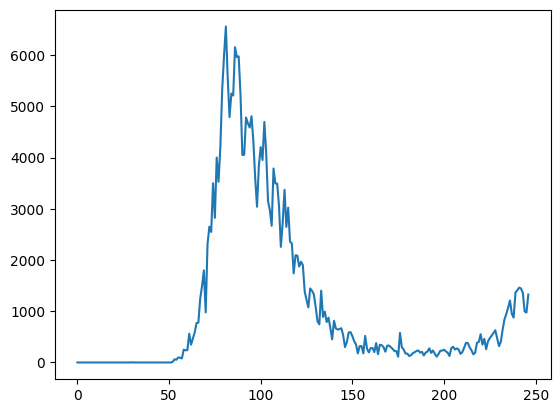

In [133]:
result_df.new_cases.plot()

In [134]:
result_df.set_index('date', inplace =True)

In [135]:
result_df

,new_cases,total_cases,new_deaths,total_deaths,new_tests,total_tests,cases_per_million,deaths_per_million,tests_per_million
date,,,,,,,,,
2020-01-01,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
2020-01-02,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
2020-01-03,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
2020-01-04,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
2020-01-05,0.0,0.0,0.0,0.0,NaN,NaN,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
2020-08-30,1444.0,267298.5,1.0,35473.0,53541.0,5117788.0,4420.946386,586.700753,84644.943252
2020-08-31,1365.0,268663.5,4.0,35477.0,42583.0,5160371.0,4443.522614,586.766910,85349.238862
2020-09-01,996.0,269659.5,6.0,35483.0,54395.0,5214766.0,4459.995818,586.866146,86248.897403


In [136]:
result_df.loc['2020-09-01']

new_cases             9.960000e+02
total_cases           2.696595e+05
new_deaths            6.000000e+00
total_deaths          3.548300e+04
new_tests             5.439500e+04
total_tests           5.214766e+06
cases_per_million     4.459996e+03
deaths_per_million    5.868661e+02
tests_per_million     8.624890e+04
Name: 2020-09-01 00:00:00, dtype: float64

<Axes: xlabel='date'>

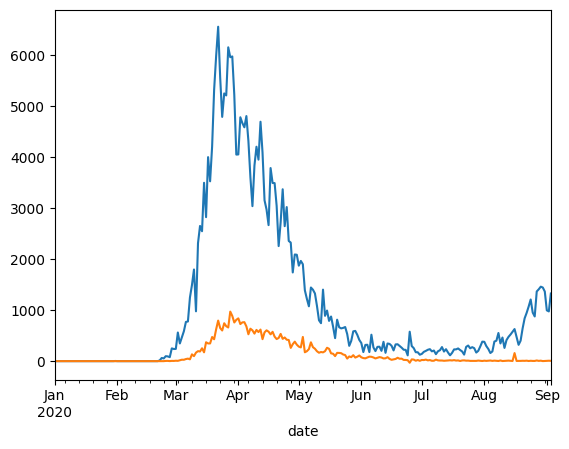

In [138]:
result_df.new_cases.plot()
result_df.new_deaths.plot()

<Axes: title={'center': 'Death Rate'}, xlabel='date'>

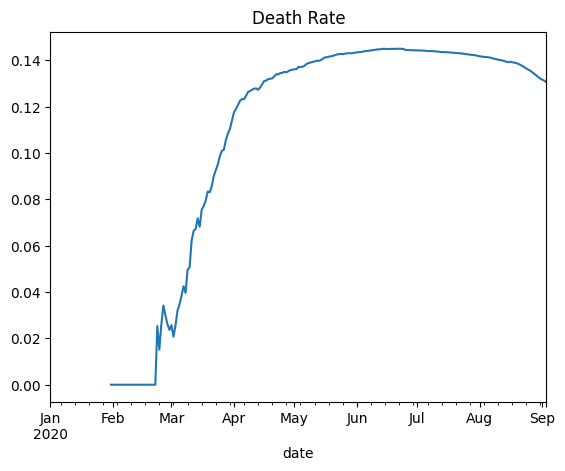

In [139]:
death_rate = result_df.total_deaths / result_df.total_cases
death_rate.plot(title='Death Rate')

<Axes: title={'center': 'Positive Rate'}, xlabel='date'>

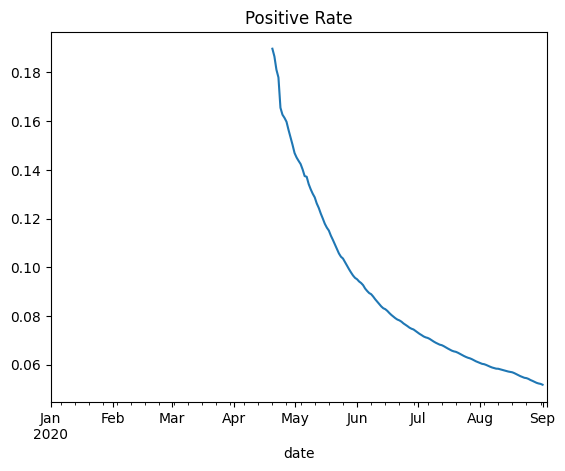

In [144]:
positive_rates = result_df.total_cases / result_df.total_tests
positive_rates.plot(title='Positive Rate')

<Axes: >

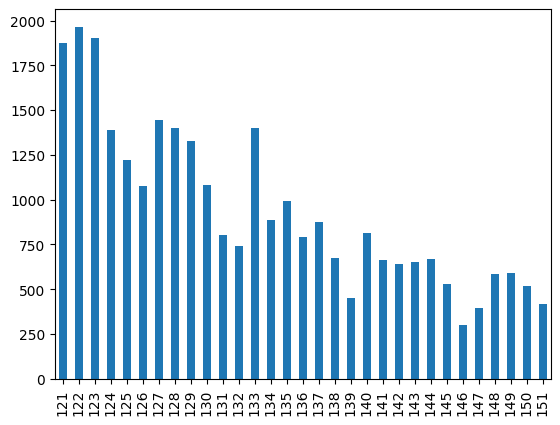

In [147]:
covid_may.new_cases.plot(kind='bar')